# Análisis de discurso computacional: AMLO vs. Petro

**Tesis de maestría — FSOC UBA**
*Neoliberalismo, desgaste de la representación y ascenso electoral de alternativas en México y Colombia (1990–2022)*

Andrés Acosta Gaviria · Directora: Ana Belén Mercado

---

Este notebook documenta el pipeline de análisis de discurso computacional construido para la tesis, aplicado a un corpus de discursos de campaña de Andrés Manuel López Obrador (México, 2018) y Gustavo Petro (Colombia, 2022). El objetivo no es solo mostrar resultados, sino **documentar el razonamiento metodológico**: qué métricas se eligieron, qué alternativas se descartaron y por qué, y qué limitaciones tiene el análisis en su estado actual.

**Pregunta de investigación (recorte para este análisis):** ¿cómo construyen discursivamente estos candidatos la crítica al bloque de poder dominante ("cartel"), la representación popular y la promesa de ruptura con el modelo neoliberal, y cómo evoluciona esa construcción a lo largo de la campaña?


## 1. Construcción del corpus

El corpus se construyó en tres fases previas a este notebook:

1. **Transcripción automática** (`yt-dlp` + Whisper de OpenAI): descarga y transcripción de discursos de campaña en video/audio, con marcas de tiempo, organizados en `.docx` por candidato.
2. **Extracción y limpieza** (`build_corpus.py`, `clean.py`): se extrae el texto de cada `.docx`, se purifican marcas de tiempo y ruido del transcriptor, y se triangulan las fechas de cada discurso contra el log del transcriptor.
3. **Modelado lingüístico** (`analisis_gramatical.py`): tokenización y lematización con spaCy (`es_core_news_lg`), excluyendo nombres propios (PROPN) para evitar que la toponimia y los nombres de personas contaminen los análisis de frecuencia.

Este notebook arranca desde el output de esa Fase 3: `dataset_tokens_analizados.csv`, una matriz atómica de tokens con metadata (candidato, fecha, lema, categoría gramatical).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.unicode_minus"] = False

CANDIDATO_A = "AMLO"
CANDIDATO_B = "Petro"

df = pd.read_csv("dataset_tokens_analizados.csv")
df["palabra_lema"] = df["palabra_lema"].astype(str).str.lower().str.strip()
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

print(f"Total de tokens en el corpus: {len(df):,}")
print(f"Discursos únicos: {df['archivo_origen'].nunique()}")
print()
print("Por candidato:")
resumen = df.groupby("candidato").agg(
    tokens=("palabra_lema", "size"),
    discursos=("archivo_origen", "nunique"),
    fecha_min=("fecha", "min"),
    fecha_max=("fecha", "max"),
)
resumen


Total de tokens en el corpus: 87,761
Discursos únicos: 105

Por candidato:


,tokens,discursos,fecha_min,fecha_max
candidato,,,,
AMLO,17119,54,2016-04-13,2018-07-02
Petro,70642,51,2021-11-02,2022-06-19


**Nota sobre el corpus:** hay una asimetría considerable entre candidatos —AMLO aporta ~54 discursos pero solo ~17 mil tokens frente a los ~51 discursos y ~71 mil tokens de Petro—, probablemente porque los discursos de Petro transcritos son en promedio más extensos. Por eso **todas las comparaciones entre candidatos usan CPM (cuentas por millón)** y no frecuencias absolutas: de lo contrario, cualquier diferencia observada podría deberse simplemente a que hay más texto de un candidato que del otro, no a un patrón discursivo real.


## 2. Decisiones metodológicas y qué se descartó

Antes de los resultados, vale la pena documentar el camino que llevó al diseño actual — incluyendo los callejones sin salida, porque son parte del aprendizaje metodológico:

**Por qué CPM y no frecuencia absoluta ni proporción simple.** Normalizar por millón de tokens (en vez de, por ejemplo, porcentaje del corpus) es una convención estándar en lingüística de corpus que hace los números más legibles y comparables entre corpus de tamaños muy distintos — como es el caso acá.

**Por qué log-ratio (Hardie, 2014) y no un ratio simple para medir especificidad léxica.** Un ratio simple de frecuencias relativas exagera desproporcionadamente las palabras raras (una palabra que aparece 1 vez en A y 0 en B da un ratio infinito o indefinido). El log-ratio normalizado con suavizado de Laplace (+1) es más robusto frente a este problema y es el estándar recomendado para corpus de tamaños distintos.

**Por qué se excluyeron los nombres propios (PROPN) de la tokenización.** Sin este filtro, los términos más frecuentes en cualquier análisis terminan siendo topónimos ("México", "Bogotá") o nombres de terceros, lo cual no aporta a la pregunta de investigación y desplaza a las palabras temáticamente relevantes.

**Por qué se descartó TF-IDF como métrica central** (la función `calcular_tfidf_firmas()` sigue en el script pero no se ejecuta en el pipeline final). Incluso con los nombres propios filtrados, el TF-IDF seguía capturando toponimia residual y ruido idiosincrático de documentos individuales en vez de vocabulario temáticamente distintivo.

**Por qué se descartaron los bigramas** (la función `analizar_red_bigramas()` también quedó en el script sin ejecutarse). La lematización con el modelo `sm` de spaCy producía errores sistemáticos (por ejemplo, "público" lematizado como "publicar"), lo que generaba bigramas espurios. Se resolvió pasando a `es_core_news_lg`, pero para entonces ya se había optado por priorizar los bloques teóricos (ver Dimensión 4) como forma más controlada metodológicamente de capturar co-ocurrencia temática.

**Por qué se descartó BERTopic.** Con ~33 a 51 discursos de campaña por candidato, el corpus es demasiado chico para que un modelo de topic modeling no supervisado como BERTopic produzca clusters estables y interpretables (UMAP + HDBSCAN tienden a colapsar casi todo en la clase de "ruido" con corpus de este tamaño). Los bloques teóricos operacionalizados a mano (Dimensión 4) cumplen una función similar — agrupar vocabulario temáticamente— pero con mayor control metodológico y anclaje teórico explícito, a costa de mayor intervención manual en la definición de las categorías.

**Ruido léxico vs. corpus completo.** El filtro de palabras vacías específico del dominio (`RUIDO_UNIFICADO`: topónimos genéricos, cargos, marcadores discursivos orales como "entonces", "bueno", "pues") se aplica *solo* en los análisis de frecuencia, nunca en la tokenización misma — así no se pierde información de contexto que podría ser útil en otros análisis futuros (por ejemplo, ventanas de co-ocurrencia).


## 3. Dimensión 1 — Vocabulario más frecuente (CPM) y su evolución temporal

Punto de partida descriptivo: ¿qué lemas dominan el discurso de cada candidato, normalizados por millón de tokens, y cómo evolucionan en el tiempo?


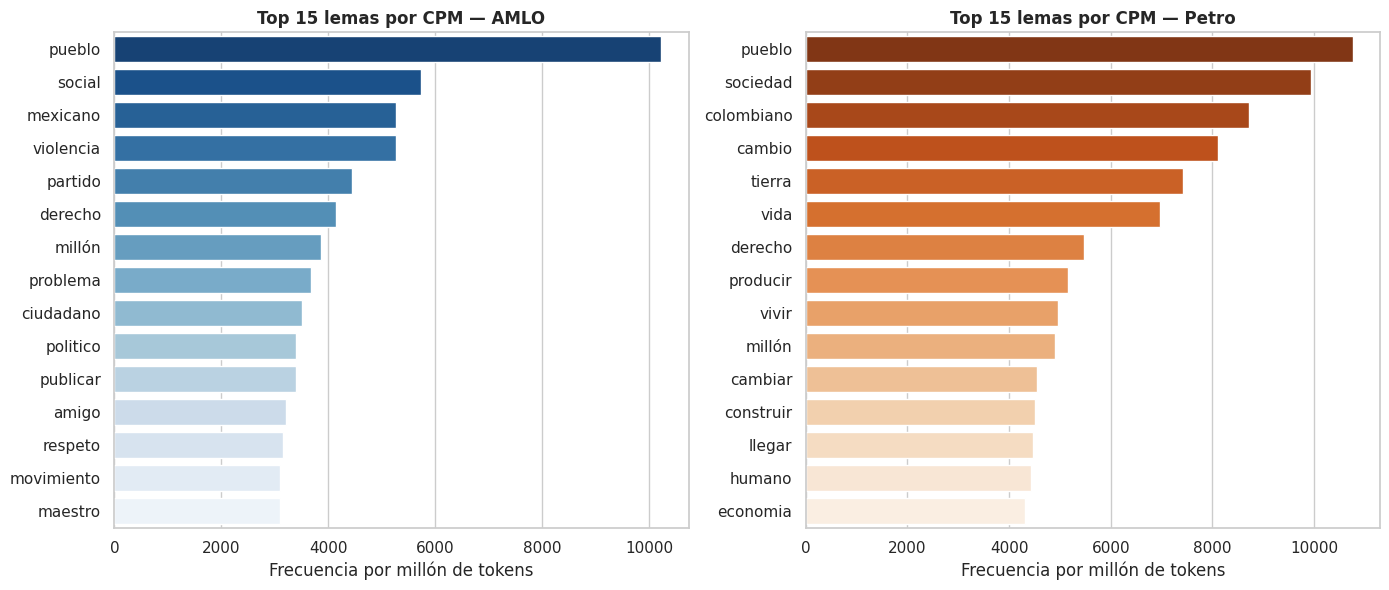

In [2]:
RUIDO_UNIFICADO = {
    "mexico", "colombia", "nacional", "republica", "estado", "pais",
    "ciudad", "region", "departamento", "municipio", "federacion",
    "latinoamerica", "america", "mundo", "gobierno",
    "presidente", "gobernador", "senador", "contralor", "ministro",
    "secretario", "candidato", "dirigente", "lider", "compañero",
    "señor", "señora", "doctor", "licenciado",
    "ano", "año", "mes", "dia", "hoy", "ayer", "semana", "momento",
    "tiempo", "vez", "periodo", "epoca", "fecha",
    "entonces", "bueno", "ahora", "aqui", "ahi", "pues", "claro",
    "bien", "verdad", "decir", "hacer", "ir", "venir", "tener",
    "poder", "querer", "saber", "ver", "dar", "haber",
    "millon", "millones", "mil", "cien", "ciento", "peso",
    "moreira", "humberto", "bautista", "pan",
    "gente",
}

def filtrar_ruido(df):
    return df[~df["palabra_lema"].isin(RUIDO_UNIFICADO)].copy()

def total_tokens_por_candidato(df):
    return df.groupby("candidato").size().to_dict()

totales = total_tokens_por_candidato(df)

def top_cpm(df, candidato, totales, top_n=15, pos_filter=None):
    sub = df[df["candidato"] == candidato].copy()
    if pos_filter:
        sub = sub[sub["categoria_gramatical"] == pos_filter]
    conteos = sub["palabra_lema"].value_counts().head(top_n).reset_index()
    conteos.columns = ["lema", "count"]
    conteos["cpm"] = (conteos["count"] / totales[candidato]) * 1_000_000
    return conteos

df_filtrado = filtrar_ruido(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cand, color in zip(axes, [CANDIDATO_A, CANDIDATO_B], ["Blues_r", "Oranges_r"]):
    top = top_cpm(df_filtrado, cand, totales, top_n=15)
    sns.barplot(data=top, x="cpm", y="lema", hue="lema", palette=color, legend=False, ax=ax)
    ax.set_title(f"Top 15 lemas por CPM — {cand}", fontweight="bold")
    ax.set_xlabel("Frecuencia por millón de tokens")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


**Evolución temporal de los 5 términos más frecuentes**, normalizada por día (CPM diario) para no confundir "más discursos ese día" con "más énfasis en ese concepto".


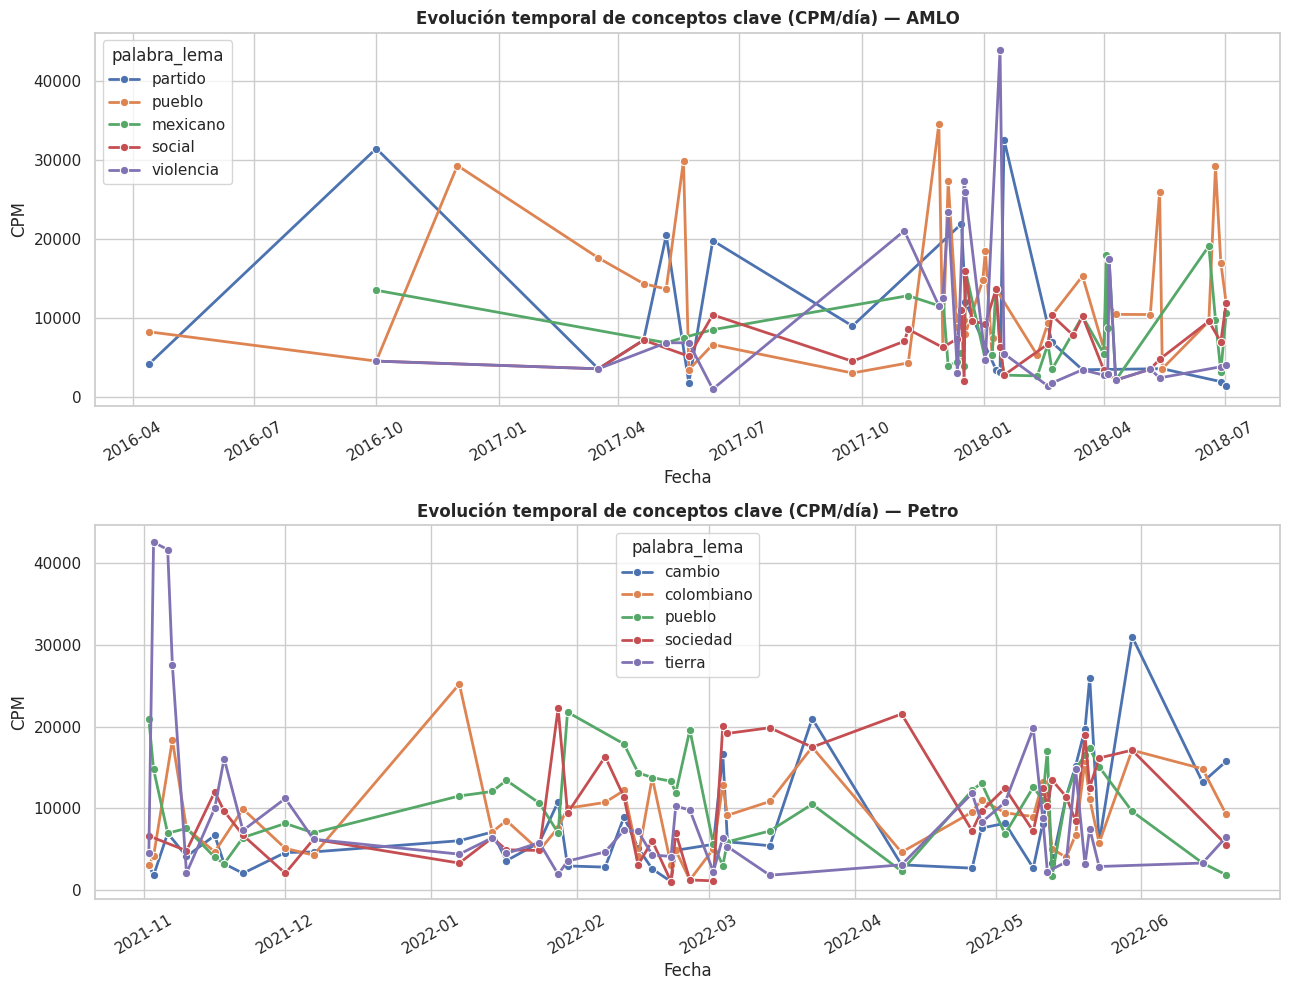

In [3]:
def evolucion_top5(df, df_filtrado, cand, totales, top_n=5):
    top = top_cpm(df_filtrado, cand, totales, top_n=top_n)
    top5 = top["lema"].tolist()
    df_cand = df[df["candidato"] == cand].copy()
    df_top5 = df_cand[df_cand["palabra_lema"].isin(top5)]
    total_dia = df_cand.groupby("fecha").size().rename("total_dia")
    evolucion = (
        df_top5.groupby(["fecha", "palabra_lema"]).size().rename("count").reset_index()
        .merge(total_dia, on="fecha")
    )
    evolucion["cpm"] = (evolucion["count"] / evolucion["total_dia"]) * 1_000_000
    return evolucion.sort_values("fecha")

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
for ax, cand in zip(axes, [CANDIDATO_A, CANDIDATO_B]):
    evol = evolucion_top5(df, df_filtrado, cand, totales)
    sns.lineplot(data=evol, x="fecha", y="cpm", hue="palabra_lema", marker="o", linewidth=2, ax=ax)
    ax.set_title(f"Evolución temporal de conceptos clave (CPM/día) — {cand}", fontweight="bold")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("CPM")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 4. Dimensión 2 — Asimetría léxica contrastiva (log-ratio, Hardie 2014)

¿Qué palabras son proporcionalmente mucho más características de un candidato que del otro? Se calcula con suavizado de Laplace (+1) para evitar `log(0)` y hacerlo robusto frente a corpus de tamaño desigual.


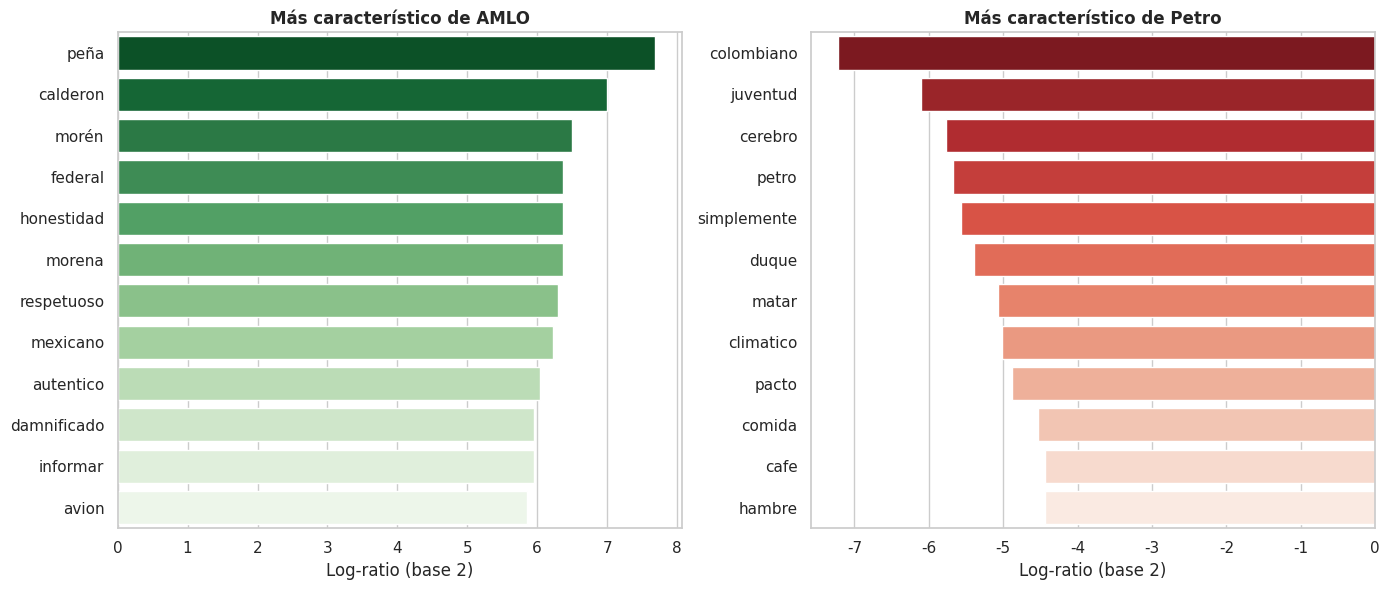

In [4]:
pivot = df_filtrado.groupby(["palabra_lema", "candidato"]).size().unstack(fill_value=0)
for cand in [CANDIDATO_A, CANDIDATO_B]:
    if cand not in pivot.columns:
        pivot[cand] = 0

n_a, n_b = totales[CANDIDATO_A], totales[CANDIDATO_B]
pivot["rel_a"] = (pivot[CANDIDATO_A] + 1) / n_a
pivot["rel_b"] = (pivot[CANDIDATO_B] + 1) / n_b
pivot["log_ratio"] = np.log2(pivot["rel_a"] / pivot["rel_b"])
pivot = pivot.reset_index()

excl_a = pivot.nlargest(12, "log_ratio")[["palabra_lema", "log_ratio"]]
excl_b = pivot.nsmallest(12, "log_ratio")[["palabra_lema", "log_ratio"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=excl_a, x="log_ratio", y="palabra_lema", hue="palabra_lema", palette="Greens_r", legend=False, ax=axes[0])
axes[0].set_title(f"Más característico de {CANDIDATO_A}", fontweight="bold")
axes[0].set_xlabel("Log-ratio (base 2)")
axes[0].set_ylabel("")

sns.barplot(data=excl_b, x="log_ratio", y="palabra_lema", hue="palabra_lema", palette="Reds_r", legend=False, ax=axes[1])
axes[1].set_title(f"Más característico de {CANDIDATO_B}", fontweight="bold")
axes[1].set_xlabel("Log-ratio (base 2)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


## 5. Dimensión 3 — Construcción discursiva del adversario

Se definieron lexicones *a priori*, fundamentados en la literatura de cada caso (no derivados de los datos), de los términos con que cada candidato construye a su adversario político: la "mafia del poder" y el bloque conservador-neoliberal para AMLO; el uribismo, el paramilitarismo y la élite extractivista para Petro. Son campos **asimétricos y no intercambiables** entre candidatos, porque responden a historias políticas distintas.


,candidato,tokens_campo_adversario,cpm_campo_adversario
0,AMLO,178,10397.80361
1,Petro,352,4982.87138


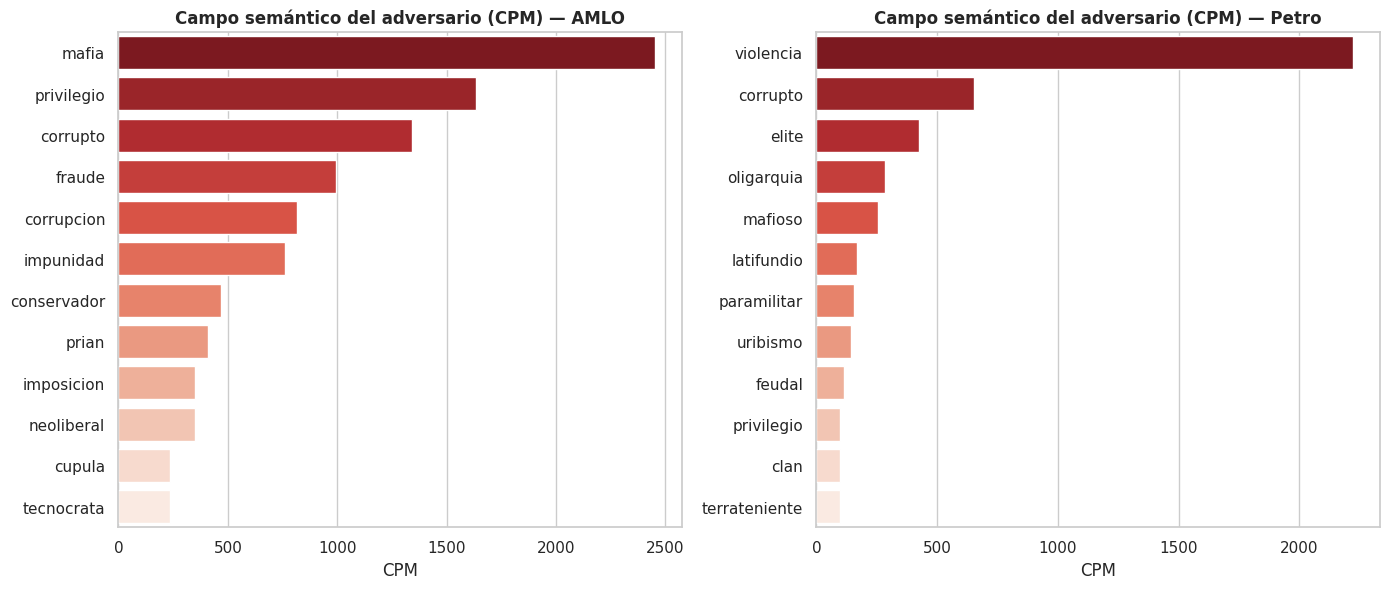

In [5]:
CAMPOS_ADVERSARIO = {
    CANDIDATO_A: [
        "mafia", "conservador", "oligarca", "corrupto", "corrupcion",
        "prian", "privilegio", "neoliberal", "tecnocrata", "cacique",
        "traidor", "impostor", "fifi", "bloque", "oligarquia",
        "imposicion", "fraude", "robo", "saqueo", "impunidad",
        "cartel", "plutocrata", "rapaz", "parasito", "cupula",
    ],
    CANDIDATO_B: [
        "oligarquia", "uribismo", "paramilitar", "clan", "casta",
        "corrupto", "corrupcion", "elite", "establecimiento", "gamonal",
        "latifundio", "mafioso", "cacique", "privilegio", "extractivismo",
        "narco", "paraestado", "violencia", "despojo", "represion",
        "feudal", "rentista", "terrateniente", "milico", "clientelismo",
    ],
}

densidad = []
for cand, campo in CAMPOS_ADVERSARIO.items():
    df_cand = df[df["candidato"] == cand]
    en_campo = df_cand[df_cand["palabra_lema"].isin(campo)]
    cpm = (len(en_campo) / totales[cand]) * 1_000_000
    densidad.append({"candidato": cand, "tokens_campo_adversario": len(en_campo), "cpm_campo_adversario": cpm})

df_densidad = pd.DataFrame(densidad)
display(df_densidad)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cand, color in zip(axes, [CANDIDATO_A, CANDIDATO_B], ["Reds_r", "Reds_r"]):
    campo = CAMPOS_ADVERSARIO[cand]
    en_campo = df[df["candidato"] == cand]
    en_campo = en_campo[en_campo["palabra_lema"].isin(campo)]
    freq = en_campo["palabra_lema"].value_counts().reset_index()
    freq.columns = ["termino", "count"]
    freq["cpm"] = (freq["count"] / totales[cand]) * 1_000_000
    sns.barplot(data=freq.head(12), x="cpm", y="termino", hue="termino", palette=color, legend=False, ax=ax)
    ax.set_title(f"Campo semántico del adversario (CPM) — {cand}", fontweight="bold")
    ax.set_xlabel("CPM")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 6. Dimensión 4 — Bloques teóricos: densidad CPM y evolución temporal

Tres categorías operacionalizadas a partir del marco teórico de la tesis, con lexicones propios (no intercambiables) por candidato:

- **Representación popular** — vocabulario de apelación a "el pueblo", los sectores populares (conecta con Pitkin, 1967)
- **Crítica al cartel** — vocabulario de denuncia del bloque de poder dominante como cartelizado (Katz y Mair, 2009)
- **Ruptura con el modelo** — vocabulario de promesa de cambio/transformación frente al orden neoliberal


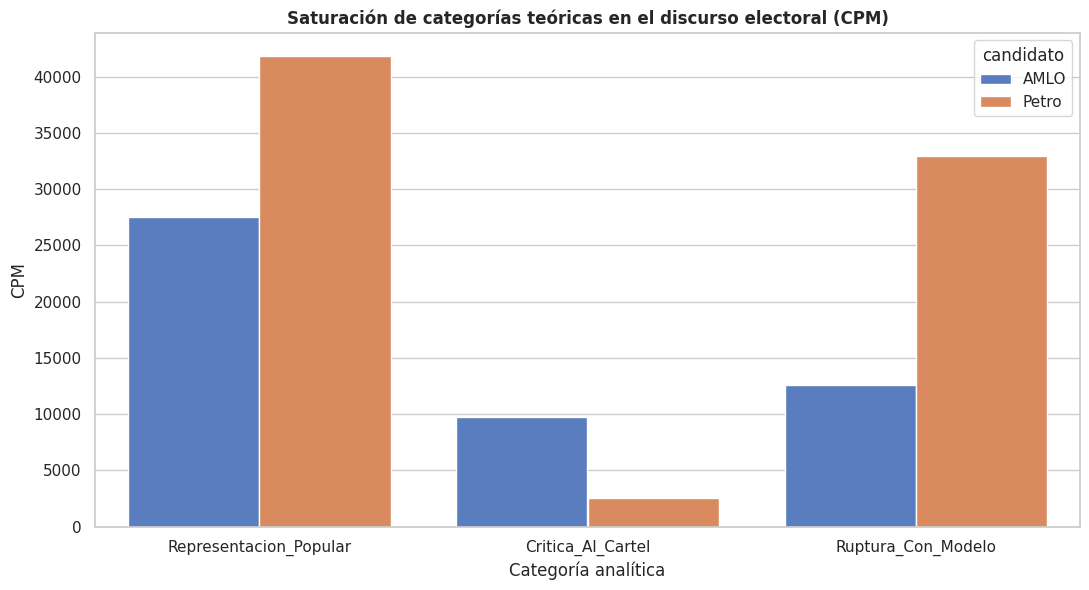

candidato,AMLO,Petro
categoria_teorica,,
Critica_Al_Cartel,9755.2,2533.9
Representacion_Popular,27571.7,41816.5
Ruptura_Con_Modelo,12559.1,32940.7


In [6]:
BLOQUES_TEORICOS = {
    CANDIDATO_A: {
        "Representacion_Popular": [
            "pueblo", "ciudadano", "pobre", "trabajador", "humilde",
            "marginado", "necesitado", "comunidad", "base", "mayoria",
            "abajo", "popular", "nacion", "patria", "hermano", "obrero",
            "campesino", "indigena", "mujer", "joven",
        ],
        "Critica_Al_Cartel": [
            "mafia", "corrupto", "corrupcion", "prian", "privilegio",
            "conservador", "oligarca", "fifi", "tecnocrata", "imposicion",
            "fraude", "robo", "saqueo", "impunidad", "traicion", "cacique",
            "nepotismo", "cartel", "captura", "oligarquia",
        ],
        "Ruptura_Con_Modelo": [
            "transformacion", "cambio", "historia", "cuarta", "regeneracion",
            "honestidad", "justicia", "austeridad", "soberania", "autonomia",
            "independencia", "liberacion", "rescate", "refundacion",
            "alternativa", "esperanza", "nuevo", "ruptura", "proyecto",
        ],
    },
    CANDIDATO_B: {
        "Representacion_Popular": [
            "pueblo", "ciudadano", "excluido", "joven", "pobreza",
            "comunidad", "humilde", "campesino", "indigena", "obrero",
            "trabajador", "mayoria", "hermano", "vida", "mujer",
            "victima", "pobre", "base", "popular", "periferia",
        ],
        "Critica_Al_Cartel": [
            "oligarquia", "uribismo", "casta", "clan", "paramilitar",
            "corrupto", "corrupcion", "elite", "establecimiento", "gamonal",
            "latifundio", "mafioso", "cacique", "privilegio", "extractivismo",
            "narco", "despojo", "represion", "clientelismo", "captura",
        ],
        "Ruptura_Con_Modelo": [
            "pacto", "cambio", "paz", "historico", "democracia", "potencia",
            "vida", "transicion", "justicia", "soberania", "reforma",
            "transformacion", "alternativa", "futuro", "esperanza",
            "posneoliberal", "nuevo", "ruptura", "proyecto", "refundacion",
        ],
    },
}

resultados = []
for cand, categorias in BLOQUES_TEORICOS.items():
    df_cand = df[df["candidato"] == cand]
    for categoria, palabras in categorias.items():
        en_cat = df_cand[df_cand["palabra_lema"].isin(palabras)]
        cpm = (len(en_cat) / totales[cand]) * 1_000_000
        resultados.append({"candidato": cand, "categoria_teorica": categoria,
                            "frecuencia_absoluta": len(en_cat), "cpm": cpm})

df_bloques = pd.DataFrame(resultados)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=df_bloques, x="categoria_teorica", y="cpm", hue="candidato", palette="muted", ax=ax)
ax.set_title("Saturación de categorías teóricas en el discurso electoral (CPM)", fontweight="bold")
ax.set_xlabel("Categoría analítica")
ax.set_ylabel("CPM")
plt.tight_layout()
plt.show()

df_bloques.pivot(index="categoria_teorica", columns="candidato", values="cpm").round(1)


## 7. Dimensión 5 — Evolución temporal comparada (día relativo)

AMLO hizo campaña en 2018 y Petro en 2021–2022: comparar por fecha calendario no tiene sentido. Se normaliza cada campaña a **día relativo** (Día 0 = primer discurso registrado de cada candidato), lo que permite comparar el *timing* discursivo de ambas campañas en una escala común, con densidad CPM por día.


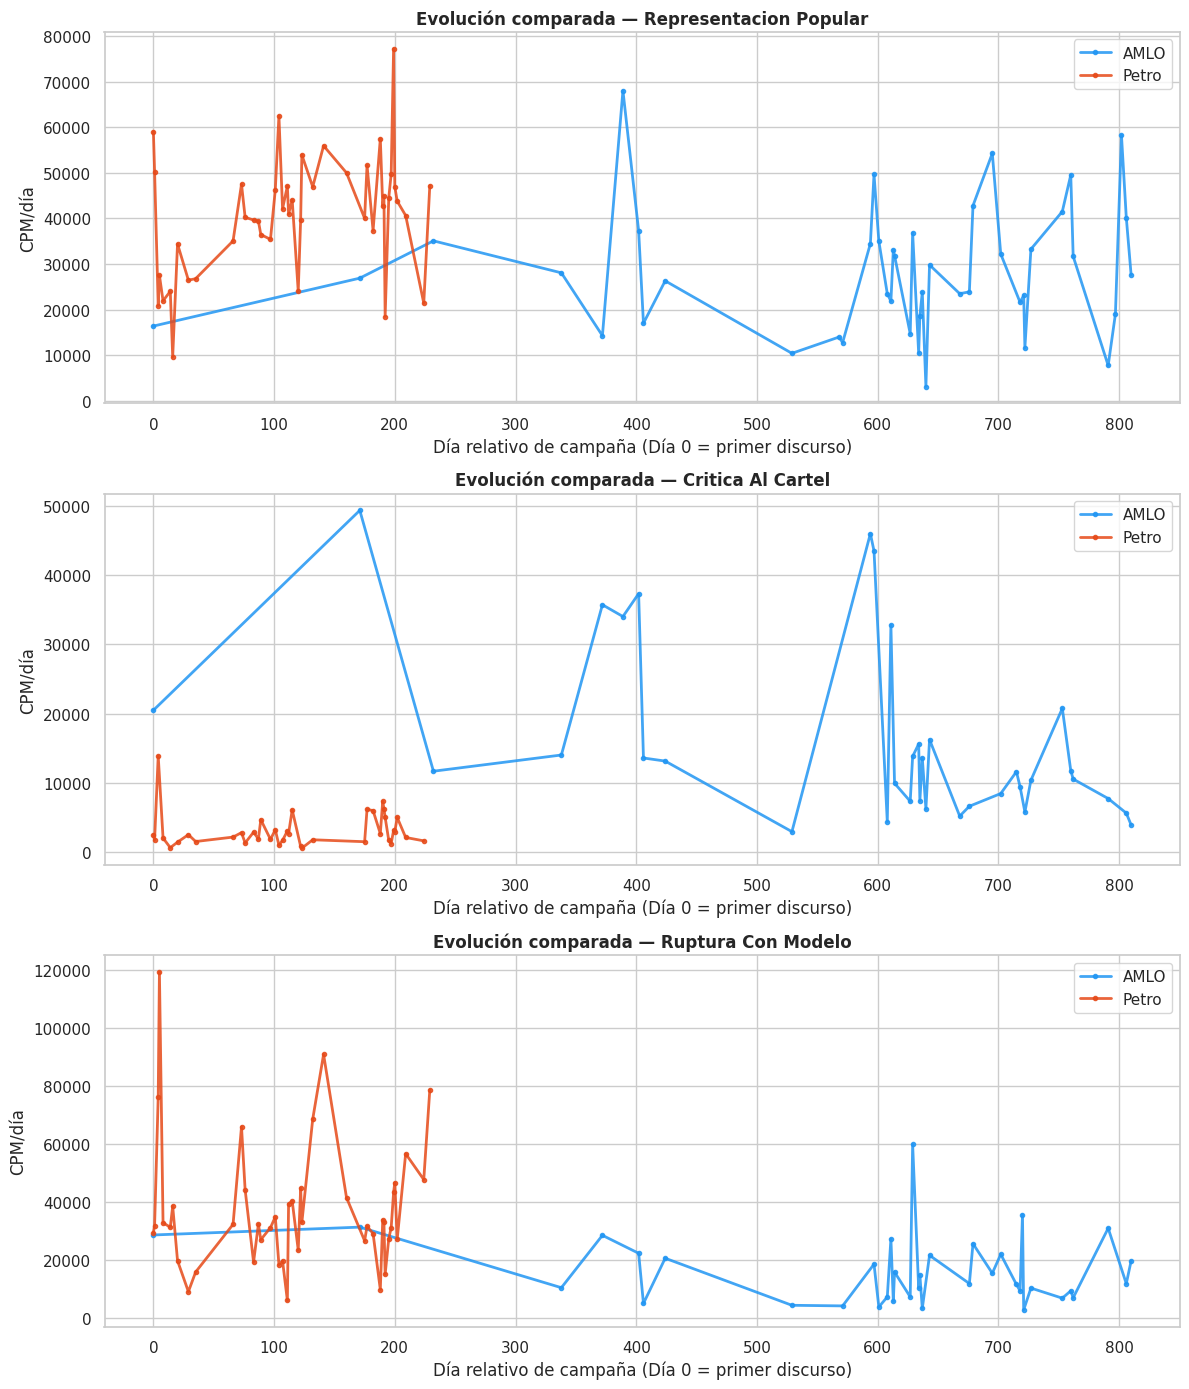

In [7]:
df_tiempo = df.copy()
fecha_inicio = df_tiempo.groupby("candidato")["fecha"].min().rename("fecha_inicio")
df_tiempo = df_tiempo.merge(fecha_inicio, on="candidato")
df_tiempo["dia_relativo"] = (df_tiempo["fecha"] - df_tiempo["fecha_inicio"]).dt.days

registros = []
for cand, categorias in BLOQUES_TEORICOS.items():
    df_cand = df_tiempo[df_tiempo["candidato"] == cand]
    total_dia = df_cand.groupby("dia_relativo").size().rename("total_dia")
    for categoria, palabras in categorias.items():
        en_cat = df_cand[df_cand["palabra_lema"].isin(palabras)]
        if en_cat.empty:
            continue
        por_dia = (en_cat.groupby("dia_relativo").size().rename("count").reset_index()
                   .merge(total_dia, on="dia_relativo"))
        por_dia["cpm"] = (por_dia["count"] / por_dia["total_dia"]) * 1_000_000
        por_dia["categoria"] = categoria
        por_dia["candidato"] = cand
        registros.append(por_dia)

df_comp = pd.concat(registros, ignore_index=True)
colores = {CANDIDATO_A: "#2196F3", CANDIDATO_B: "#E64A19"}

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
for ax, categoria in zip(axes, ["Representacion_Popular", "Critica_Al_Cartel", "Ruptura_Con_Modelo"]):
    sub = df_comp[df_comp["categoria"] == categoria]
    for cand in [CANDIDATO_A, CANDIDATO_B]:
        data_cand = sub[sub["candidato"] == cand].sort_values("dia_relativo")
        ax.plot(data_cand["dia_relativo"], data_cand["cpm"], label=cand,
                color=colores[cand], linewidth=2, marker="o", markersize=3, alpha=0.85)
    ax.set_title(f"Evolución comparada — {categoria.replace('_', ' ')}", fontweight="bold")
    ax.set_xlabel("Día relativo de campaña (Día 0 = primer discurso)")
    ax.set_ylabel("CPM/día")
    ax.legend()
plt.tight_layout()
plt.show()


## 8. Dimensión 6 — Keyness (G²)

El estadístico de asociación léxica G² (log-likelihood) identifica qué palabras están significativamente sobrerrepresentadas en el discurso de un candidato frente al otro, comparando frecuencias observadas contra las esperadas bajo una distribución conjunta. A diferencia del log-ratio (Dimensión 2), que mide *magnitud* de la asimetría, G² pondera también la *frecuencia absoluta* — por lo que tiende a priorizar palabras frecuentes con diferencias significativas, en vez de palabras raras con ratios extremos.


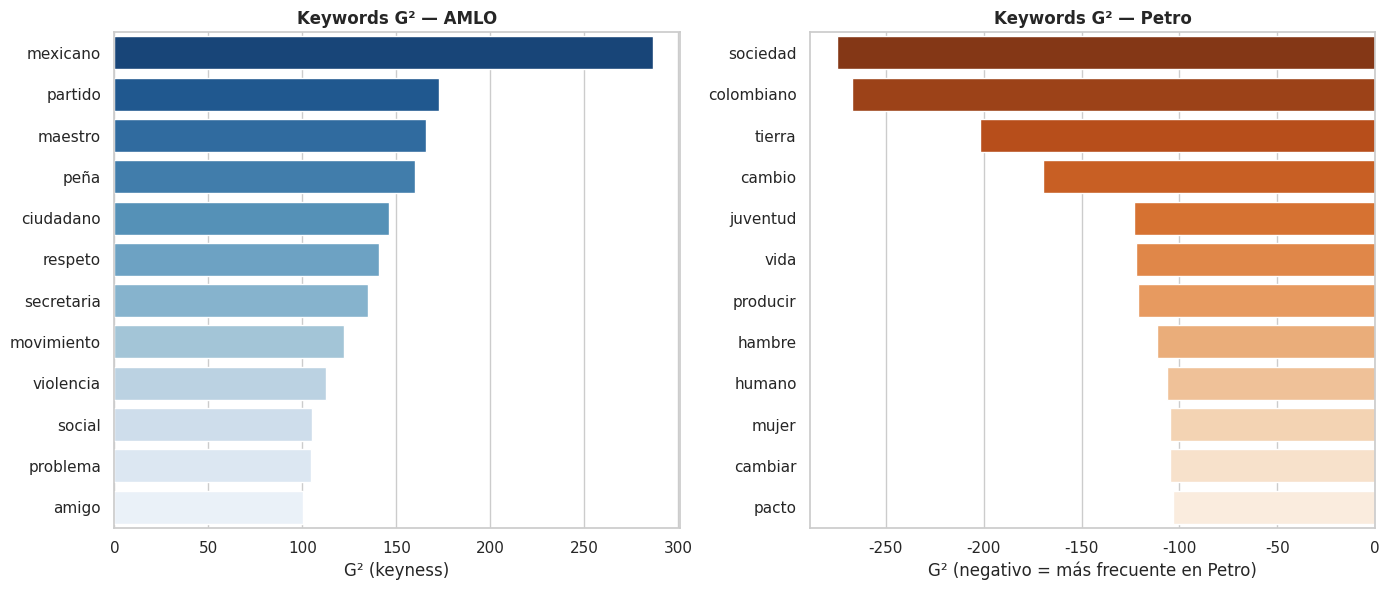

In [8]:
freq = df_filtrado.groupby(["candidato", "palabra_lema"]).size().reset_index(name="count")
for cand in [CANDIDATO_A, CANDIDATO_B]:
    freq.loc[freq["candidato"] == cand, "total"] = totales[cand]
freq["cpm"] = (freq["count"] / freq["total"]) * 1_000_000

pivot_g2 = freq.pivot(index="palabra_lema", columns="candidato", values="count").fillna(0)
for cand in [CANDIDATO_A, CANDIDATO_B]:
    if cand not in pivot_g2.columns:
        pivot_g2[cand] = 0

n_a, n_b = totales[CANDIDATO_A], totales[CANDIDATO_B]
pivot_g2["total_obs"] = pivot_g2[CANDIDATO_A] + pivot_g2[CANDIDATO_B]
total_general = n_a + n_b
pivot_g2["exp_a"] = (pivot_g2["total_obs"] * n_a) / total_general
pivot_g2["exp_b"] = (pivot_g2["total_obs"] * n_b) / total_general

def log_lik(obs, exp):
    if obs == 0 or exp == 0:
        return 0.0
    return 2 * obs * np.log(obs / exp)

pivot_g2["g2_a"] = pivot_g2.apply(lambda r: log_lik(r[CANDIDATO_A], r["exp_a"]), axis=1)
pivot_g2["g2_b"] = pivot_g2.apply(lambda r: log_lik(r[CANDIDATO_B], r["exp_b"]), axis=1)
pivot_g2["keyness"] = np.where(pivot_g2[CANDIDATO_A] > pivot_g2["exp_a"], pivot_g2["g2_a"], -pivot_g2["g2_b"])

df_keyness = pivot_g2[["keyness", "total_obs", CANDIDATO_A, CANDIDATO_B]].sort_values("keyness", ascending=False)
top_a = df_keyness.head(12).reset_index()
top_b = df_keyness.tail(12).sort_values("keyness").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_a, x="keyness", y="palabra_lema", hue="palabra_lema", palette="Blues_r", legend=False, ax=axes[0])
axes[0].set_title(f"Keywords G² — {CANDIDATO_A}", fontweight="bold")
axes[0].set_xlabel("G² (keyness)")
axes[0].set_ylabel("")

sns.barplot(data=top_b, x="keyness", y="palabra_lema", hue="palabra_lema", palette="Oranges_r", legend=False, ax=axes[1])
axes[1].set_title(f"Keywords G² — {CANDIDATO_B}", fontweight="bold")
axes[1].set_xlabel("G² (negativo = más frecuente en Petro)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


## 9. Limitaciones

- **Tamaño del corpus.** ~33–54 discursos de campaña por candidato es un corpus chico para métodos de aprendizaje no supervisado (de ahí el descarte de BERTopic); es adecuado para análisis de frecuencia y asociación léxica, pero limita la robustez estadística de cualquier inferencia más ambiciosa.
- **Asimetría de tamaño entre candidatos.** Petro aporta ~4 veces más tokens que AMLO en este corte del corpus, lo que refuerza la necesidad de trabajar siempre en CPM y no en conteos absolutos, y obliga a interpretar con cautela cualquier comparación donde el corpus de AMLO sea muy chico dentro de una subcategoría.
- **Lexicones definidos a priori.** Los campos semánticos del adversario y los bloques teóricos fueron construidos manualmente a partir de la literatura, no derivados empíricamente del corpus (por ejemplo, vía embeddings o co-ocurrencia). Esto da anclaje teórico pero introduce la posibilidad de sesgo de confirmación en qué términos se incluyen.
- **Contaminación residual.** Aunque se filtran nombres propios y un conjunto de palabras vacías específicas del dominio, es probable que queden términos de ruido no capturados (la lista `RUIDO_UNIFICADO` se construyó de forma iterativa y podría no ser exhaustiva).
- **Fechas "Sin Fecha".** El proceso de triangulación de fechas (`clean.py`) puede no encontrar coincidencia para algunos archivos, dejándolos fuera de los análisis de evolución temporal aunque sí se cuenten en los análisis de frecuencia agregada.


## 10. Próximos pasos

- Completar el examen cualitativo de las plataformas electorales y discursos de campaña para contrastar los hallazgos cuantitativos con lectura interpretativa directa.
- Precisar los mecanismos institucionales específicos mediante los cuales los bloques dominantes de cada país difirieron la expresión electoral de la crisis representativa.
- Evaluar si ampliar el corpus (más discursos, o incorporar coyunturas electorales intermedias) permite reconsiderar métodos como BERTopic que hoy se descartaron por tamaño insuficiente.
- Documentar formalmente la lista `RUIDO_UNIFICADO` y los lexicones de `CAMPOS_ADVERSARIO`/`BLOQUES_TEORICOS` como anexo metodológico citable en la tesis.
